In [1]:
import discovery as ds
import pathlib
import corner
import matplotlib.pyplot as plt
import discovery.samplers.numpyro as ds_numpyro

C:\Users\amirt\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from discovery.models.fourierpta import * 
from discovery.models.flowfourierpta import * 
plt.style.use("matplotlib.mplstyle")

In [3]:
feathers = pathlib.Path(ds.__path__[0] + '/../../data/')

npsr = 2
psrfiles= sorted(feathers.glob("*-[JB]*.feather"))[:npsr]
psrs = sorted(
    [ds.Pulsar.read_feather(f) for f in psrfiles],
    key=lambda psr: len(psr.toas), reverse=False
)

We run the MAP estimate below to get a good initial value for the regularizer. 

In [4]:
components = 30
gw_components = 14
powerlaw = ds.powerlaw
Tspan = ds.getspan(psrs)



eta0_prime = {"log10_A": -13.5, "gamma": 0.0} 
eta0_regularizer, results = compute_eta_MAP(psrs, powerlaw=powerlaw,
                                          priordict=priordict_standard,
                                          eta0_prime=eta0_prime,
                                          n_grid = 10, steps = 3,
                                          zoom = 0.4)




B1855+09:
eta MAP: gamma=3.61, log10_A=-13.88
informative with ratio = 0.39

B1937+21:
eta MAP: gamma=4.11, log10_A=-13.56
informative with ratio = 0.17


In [27]:
eta0_regularizer_test, results_test = compute_eta_MAP(psrs, powerlaw=powerlaw,
                                          priordict=priordict_standard,
                                          eta0_prime=eta0_prime,
                                          n_grid = 10, steps = 5,
                                          zoom = 0.7, Tspan = 3*ds.getspan(psrs))


B1855+09:
eta MAP: gamma=3.60, log10_A=-13.92
informative with ratio = 0.39

B1937+21:
eta MAP: gamma=5.87, log10_A=-11.06
informative with ratio = nan


Note that the MAP estimate will also depend on Tspan. If no Tspan is passed, it defaults to computing the Tspan on a pulsar-by-pulsar basis. In that case the MAP you obtain would be the same MAP from an SPNA run where Tspan is set to the observation span for that particular pulsar.

In [6]:
eta0_regularizer

[{'log10_A': -13.879999999999999, 'gamma': 3.608888888888888},
 {'log10_A': -13.559999999999999, 'gamma': 4.106666666666666}]

I suggest using slightly larger valeus on the amplitude to account for the nonzero variance on the IRN hyperparameters in the posterior. 

In [7]:
eta0_regularizer = [{'log10_A': -13.4, 'gamma': 3.62},
 {'log10_A': -13.1, 'gamma': 3.90}]

# Flow-corrected posterior with fixed WN

In [ ]:
noisedicts = [psr.noisedict for psr in psrs]
summaries = build_fourier_psr_summaries(
    psrs, eta0_list  = eta0_regularizer,
    powerlaw = powerlaw, components = components,
    noisedict_list = noisedicts,
    psr_class_obj = FlowPulsarFourierSummary)

In [10]:
run_step1_flow(summaries, priordict=ds.priordict_standard, learning_rate = 1e-2,
               steps = 512, batch_size = 128, n_flow_samples=100000)

[1/2] Running step 1 for B1855+09
Theta fixed. Using VI.


 26%|██▌       | 132/512 [00:17<00:51,  7.44it/s, loss=-91139.99]


Early stopping at iteration 132
Finished VI flow-fit for pulsar B1855+09.
[2/2] Running step 1 for B1937+21
Theta fixed. Using VI.


 64%|██████▍   | 327/512 [00:43<00:24,  7.55it/s, loss=-328507.39]


Early stopping at iteration 327
Finished VI flow-fit for pulsar B1937+21.
[1/2]: Running flow step for pulsar B1855+09
[2/2]: Running flow step for pulsar B1937+21


In [11]:
dsf.VariationalFit??

Init signature:
dsf.VariationalFit(
    dist,
    loss_fn,
    multibatch=1,
    optimizer=None,
    learning_rate=0.0005,
    annealing_schedule=None,
    patience=100,
    show_progress=True,
)
Docstring:      <no docstring>
Source:        
class VariationalFit:
    def __init__(self, dist, loss_fn, multibatch=1, optimizer=None, learning_rate=5e-4, annealing_schedule=None, patience=100, show_progress=True):
        """Set up a variational fit."""

        self.dist = dist
        # self.gradloss_fn = eqx.filter_jit(eqx.filter_value_and_grad(loss_fn)) - see below
        self.multibatch = multibatch

        self.optimizer = optimizer or optax.adam(learning_rate)
        params, static = eqx.partition(self.dist, eqx.is_inexact_array, is_leaf=lambda leaf: isinstance(leaf, paramax.NonTrainable))
        self.opt_state = self.optimizer.init(params)
        self.annealing_schedule = annealing_schedule or (lambda iter: 1.0)
        self.patience = patience

        # AOT: https://jax.readt

In [12]:
noisedicts = [psr.noisedict for psr in psrs]
summaries_linear = build_fourier_psr_summaries(psrs, eta0_list  = eta0_regularizer,
    powerlaw = powerlaw, components = components,
    noisedict_list = noisedicts, psr_class_obj = FlowPulsarFourierSummary)

In [13]:
run_step1_flow(summaries_linear, priordict=ds.priordict_standard, learning_rate=1e-2,
               steps=512, batch_size=128, n_flow_samples=1000000,
               flow_architecture=affine_flow_architecture)

[1/2] Running step 1 for B1855+09
Theta fixed. Using VI.


 20%|█▉        | 101/512 [00:01<00:05, 75.80it/s, loss=-91139.45]


Early stopping at iteration 101
Finished VI flow-fit for pulsar B1855+09.
[2/2] Running step 1 for B1937+21
Theta fixed. Using VI.


 20%|█▉        | 101/512 [00:00<00:03, 126.46it/s, loss=-328506.99]


Early stopping at iteration 101
Finished VI flow-fit for pulsar B1937+21.
[1/2]: Running flow step for pulsar B1855+09
[2/2]: Running flow step for pulsar B1937+21


When $\boldsymbol {\theta}$ is fixed, the distribution on the Fourier coefficients should be Gaussian. For this reason, the flow and its corresponding Gaussian approximation should coincide. 

In [14]:
def log_gauss(a, a_mean, L_f, n = 60):
    diff = a - a_mean
    return (-0.5 * n * jnp.log(2 * jnp.pi) - jnp.sum(jnp.log(jnp.diag(L_f)))
                            - 0.5 * diff @ jsp.linalg.cho_solve((L_f, True), diff))

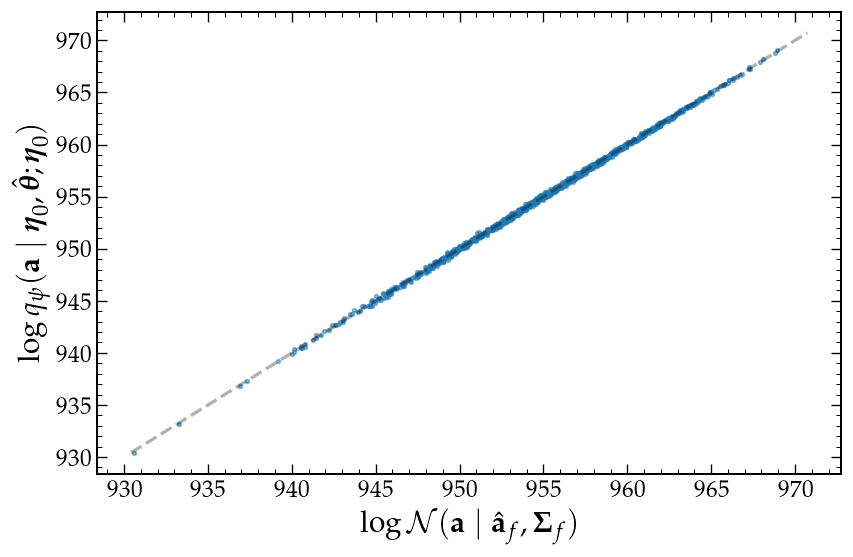

In [15]:
trained_flow = summaries[0].flow
samples_ys = trained_flow.sample(jax.random.key(0), sample_shape=(10000,))

L0 = summaries[0].L0r
ahat0 = summaries[0].ahat0r

a_samples = jax.vmap(lambda ys: L0 @ ys + ahat0)(samples_ys) 

ahat_f = summaries[0].ahat_f
Sigma_f_inv = summaries[0].TtNTf + summaries[0].phi0_inv
L_f = summaries[0].L_f
log_p_flow_vals = jax.vmap(lambda ys: trained_flow.log_prob(ys))(samples_ys)

n = 2*components
log_det_L0 = jnp.sum(jnp.log(jnp.diag(L0))) 
log_p_flow_in_a = log_p_flow_vals - log_det_L0

def log_gauss_full(a):
    diff = a - ahat_f
    return (-0.5 * n * jnp.log(2 * jnp.pi) - jnp.sum(jnp.log(jnp.diag(L_f))) - 0.5 * diff @ Sigma_f_inv @ diff)
    
log_p_gauss_vals = jax.vmap(lambda a: log_gauss(a, ahat_f, L_f))(a_samples)

plt.scatter(np.array(log_p_gauss_vals[:1000]),np.array(log_p_flow_in_a[:1000]),
            alpha=0.5, s=5,zorder = 1)

lims = [min(log_p_gauss_vals.min(), log_p_flow_in_a.min()),
        max(log_p_gauss_vals.max(), log_p_flow_in_a.max())]
plt.plot(lims, lims, color='black', linestyle='--', alpha = 0.3)
plt.xlabel(r"$\log \mathcal{N}(\mathbf{a} \mid \hat{\mathbf{a}}_f, \boldsymbol{\Sigma}_f)$")
plt.ylabel(r"$\log q_{\psi}(\mathbf{a} \mid \boldsymbol{\eta}_0, \hat{\boldsymbol{\theta}}; \boldsymbol{\eta}_0)$")
plt.show()

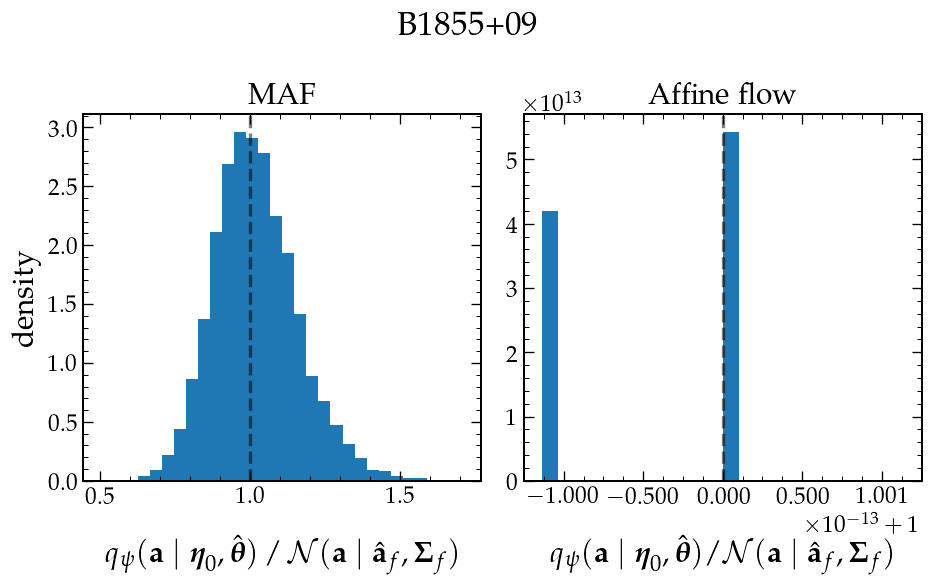

In [ ]:
fig, axes = plt.subplots(1, 2)

L0 = summaries[0].L0r
ahat0 = summaries[0].ahat0r
n = summaries[0].n_coeff
log_det_L0 = jnp.sum(jnp.log(jnp.diag(L0)))

# generate samples from flow and transf. into real space
samples_ys = summaries[0].flow.sample(jax.random.key(0), sample_shape=(10000,))
a_samples = jax.vmap(lambda ys: L0 @ ys + ahat0)(samples_ys)
# evaluate flow in real space accounting for log det (fixed here)
log_p_flow_in_a = jax.vmap(summaries[0].flow.log_prob)(samples_ys) - log_det_L0

# compare this with gaussian approx. given by ahat_f, L_f
ahat_f_mc = summaries[0].ahat_f
L_f_mc = summaries[0].L_f
Sigma_f_inv_mc = jsp.linalg.cho_solve((L_f_mc, True), jnp.eye(L_f_mc.shape[0]))

log_p_gauss_mc = jax.vmap(lambda a: log_gauss(a, ahat_f_mc, L_f_mc))(a_samples)
ratio_mc = jnp.exp(log_p_flow_in_a - log_p_gauss_mc)
ratio_mc = ratio_mc[jnp.isfinite(ratio_mc)]

axes[0].hist(np.array(ratio_mc), bins=30, density=True)
axes[0].axvline(1.0, color='black', linestyle='--', alpha=0.5)
axes[0].set_xlabel(r"$q_\psi(\mathbf{a} \mid \boldsymbol{\eta}_0, \hat{\boldsymbol{\theta}}) \,/\, \mathcal{N}(\mathbf{a} \mid \hat{\mathbf{a}}_f, \boldsymbol{\Sigma}_f)$")
axes[0].set_ylabel("density")
axes[0].set_title("MAF")

# now cf. with Affine flow y ~ Az + b 
bij = summaries_linear[0].flow.bijection
loc_flow = bij.loc # this gives us the mean in the latent space y
L_flow = bij.triangular.fn(*bij.triangular.args, **bij.triangular.kwargs) # gives us the learnt (lower triangular) called A
Sigma_f = L_flow @ L_flow.T
L0_fixed = summaries_linear[0].L0r
ahat0_fixed = summaries_linear[0].ahat0r
log_det_L0_fixed = jnp.sum(jnp.log(jnp.diag(L0_fixed)))

ahat_f_analytic = L0_fixed @ loc_flow + ahat0_fixed # mean of latent space in a ( E[Ly+b] = LE[y] + E[b] = LE[y] + b)
Sigma_f_analytic = L0_fixed @ Sigma_f @ L0_fixed.T
L_f_analytic = jnp.linalg.cholesky(Sigma_f_analytic)
Sigma_f_inv_analytic = jsp.linalg.cho_solve((L_f_analytic, True), jnp.eye(L_f_analytic.shape[0]))

# generate samples in y space and push forward to real space a using latent space transf.
samples_ys_fixed = summaries_linear[0].flow.sample(jax.random.key(0), sample_shape=(10000,))
a_samples_fixed = jax.vmap(lambda ys: L0_fixed @ ys + ahat0_fixed)(samples_ys_fixed)
# affine flow log prob accounting for log det to evaluate in real space again
log_p_flow_in_a_fixed = jax.vmap(summaries_linear[0].flow.log_prob)(samples_ys_fixed) - log_det_L0_fixed

# again compute log gauss using the analytical result
log_p_gauss_analytic = jax.vmap(lambda a: log_gauss(a, ahat_f_analytic, L_f_analytic))(a_samples_fixed)
ratio_analytic = jnp.exp(log_p_flow_in_a_fixed - log_p_gauss_analytic)
ratio_analytic = ratio_analytic[jnp.isfinite(ratio_analytic)]

axes[1].hist(np.array(ratio_analytic), bins='auto', density=True)
axes[1].axvline(1.0, color='black', linestyle='--', alpha=0.5)
axes[1].set_xlabel(r"$q_\psi(\mathbf{a} \mid \boldsymbol{\eta}_0, \hat{\boldsymbol{\theta}}) / \mathcal{N}(\mathbf{a} \mid \hat{\mathbf{a}}_f, \boldsymbol{\Sigma}_f)$")
axes[1].set_title("Affine flow")

axes[0].xaxis.labelpad = 15
axes[1].xaxis.labelpad = 15

plt.suptitle(summaries[0].name, size=20)
plt.tight_layout()
plt.show()

There is some variance associated to the flow fit for the MAF architecture. The reason for this is the finite MCMC sampling step. Compare this to the affine flow where an analytical estimate can be obtained on the Fourier coefficients, and where the ratio of the flow to the normal distribution is exact up to machine precision. Under fixed WN, the Fourier coefficients are normally-distributed.

We run a scan over $N_{fs}$ (fs for flow-samples) to estimate the scaling of the variance (for this given flow architecture).

In [ ]:
N_fs = [int(x) for x in jnp.logspace(3, 6, 8).tolist()]

trained_flow = summaries[0].flow
L0 = summaries[0].L0r
ahat0 = summaries[0].ahat0r
n = summaries[0].n_coeff
log_det_L0 = jnp.sum(jnp.log(jnp.diag(L0)))

eval_samples_ys = trained_flow.sample(jax.random.key(0), sample_shape=(10000,))
a_eval = jax.vmap(lambda ys: L0 @ ys + ahat0)(eval_samples_ys)
log_p_flow = jax.vmap(trained_flow.log_prob)(eval_samples_ys) - log_det_L0

results = {}
for n_fs in N_fs:
    compute_gauss_approx_to_flow(summaries[0], jax.random.key(1), n_flow_samples=n_fs) # this replaces ahat_f, L_f in summaries

    log_p_gauss = jax.vmap(lambda a: log_gauss(a, summaries[0].ahat_f, summaries[0].L_f))(a_eval)
    log_ratio = log_p_flow - log_p_gauss

    results[n_fs] = { "log_p_gauss": np.array(log_p_gauss), "log_ratio": np.array(log_ratio),
        "std": float(jnp.std(log_ratio)), "mean": float(jnp.mean(log_ratio))}
    print(f"N_fs={n_fs}: std={results[n_fs]['std']}")

N_fs=1000: std=1.5691947665423023
N_fs=2682: std=0.869386375142482
N_fs=7196: std=0.5215693289093802
N_fs=19306: std=0.32167262000375946
N_fs=51794: std=0.19399558822364887
N_fs=138949: std=0.11727569092941063
N_fs=372759: std=0.07024943104532341
N_fs=1000000: std=0.04536355006024582


In [ ]:
N_fs

[1000, 2682, 7196, 19306, 51794, 138949, 372759, 1000000]

In [ ]:
labels = ["19.3k", "51.8k", "139k", "373k", "1M"]
N_fsp = [n for n in N_fs if n >= 10000]

C:\Users\amirt\AppData\Local\Temp\ipykernel_12020\4147401957.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


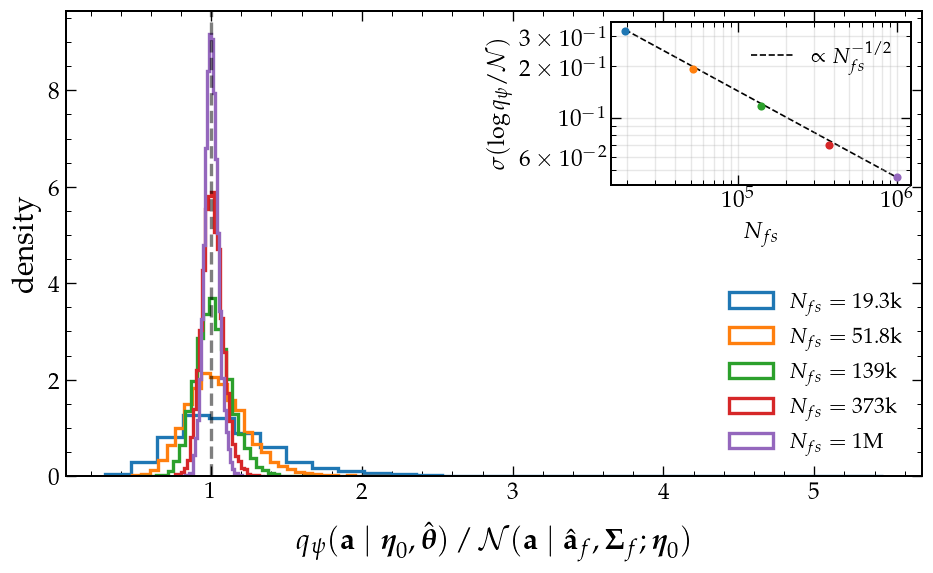

In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots()
colors = []
for n_fs, label in zip(N_fsp,labels):
    ratio = np.exp(results[n_fs]["log_ratio"])
    ratio = ratio[np.isfinite(ratio)]
    h = ax.hist(ratio, bins=30, density=True, histtype='step', lw=2, label=f"$N_{{fs}}=$ {label}" )
    colors.append(h[2][0].get_edgecolor())

ax.axvline(1.0, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel(r"$q_\psi(\mathbf{a} \mid \boldsymbol{\eta}_0, \hat{\boldsymbol{\theta}}) \,/\, \mathcal{N}(\mathbf{a} \mid \hat{\mathbf{a}}_f, \boldsymbol{\Sigma}_f ; \boldsymbol{\eta}_0)$")
ax.set_ylabel("density")
ax.legend(loc = 'lower right')
ax.xaxis.labelpad = 10

axins = inset_axes(ax, width="35%", height="35%", loc='upper right')
N_arr = jnp.array(N_fsp)
stds_plot = [results[n_fs]["std"] for n_fs in N_fsp]
scaling = stds_plot[-1] * jnp.sqrt(N_fsp[-1]) / jnp.sqrt(N_arr)

axins.loglog(N_fsp, np.array(scaling), color='black', linestyle='--',
             alpha=1, linewidth=1, label=r"$\propto N_{fs}^{-1/2}$", zorder=1)

for n_fs, std, color in zip(N_fsp, stds_plot, colors):
    axins.scatter(n_fs, std, marker='o', color=color, s=15, zorder=5)

axins.set_xlabel(r"$N_{fs}$", fontsize = 14)
axins.set_ylabel(r"$\sigma(\log q_\psi/\mathcal{N})$", fontsize = 14)
axins.grid(True, alpha=0.3, which='both')
axins.legend()

plt.tight_layout()
plt.savefig(fr"MAF_{summaries[0].name}.pdf",)
plt.show()

In [29]:
samples = run_step2_SPNA_flow_corrected(summaries[:1], psrs[:1], ds.partial(phi_SPNA, powerlaw= ds.powerlaw), priordict_standard,
                    n_warmup=1024, n_samples=4096)

[1/1] Running step 2 SPNA flow-corrected for B1855+09


sample: 100%|██████████| 5120/5120 [01:05<00:00, 77.95it/s, 31 steps of size 2.08e-01. acc. prob=0.94] 


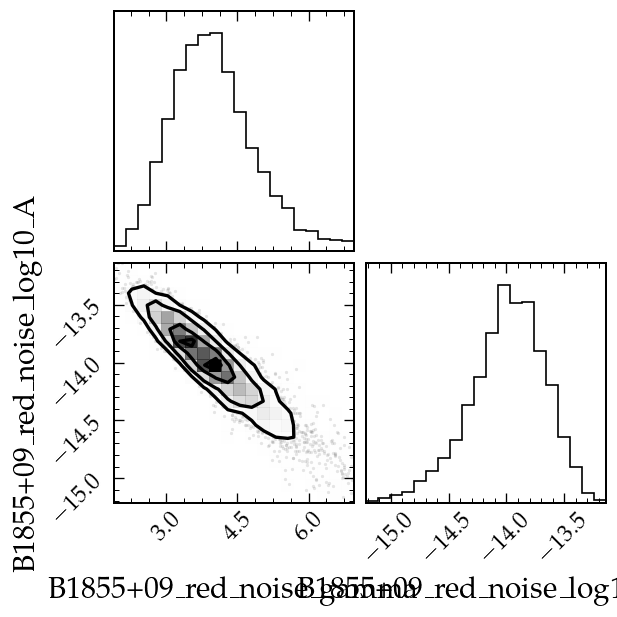

In [30]:
psr_samples = samples[summaries[0].name]
hyper_keys = [key for key in psr_samples.keys() if key not in ("y", "y_gauss", "xi", "a")]
samples_hyper = {key: psr_samples[key] for key in hyper_keys}
corner.corner(samples_hyper)
plt.show()

In [31]:
def create_rn_keys(psrnames):
    rn_amp_keys = [f"{psr_name}_red_noise_log10_A" for psr_name in psrnames]
    rn_gamma_keys = [f"{psr_name}_red_noise_gamma" for psr_name in psrnames]
    return rn_amp_keys, rn_gamma_keys

rn_amp_keys, rn_gamma_keys = create_rn_keys([s.name for s in summaries[:1]])

In [32]:
m_SPNA = ds.ArrayLikelihood([ds.PulsarLikelihood([psr.residuals,
                            ds.makegp_timing(psr, svd=True),
                            ds.makenoise_measurement(psr, noisedict=psr.noisedict, ecorr=True),
                             ds.makegp_fourier(psr, powerlaw, 30, name='red_noise', T=Tspan)]) for psr in psrs[:1]])
                          

In [33]:
import numpyro.infer as infer

In [34]:
def log_prior_rho(rho):
    
    log10As = jnp.array([rho[k] for k in rn_amp_keys])# + [rho[crn_log10A_key]])
    gammas  = jnp.array([rho[k] for k in rn_gamma_keys])# + [rho[crn_gamma_key]])

    ok = jnp.all((log10As >= -20) & (log10As <= -11)) & jnp.all((gammas >= 0) & (gammas <= 7))
    log_prior_val = jnp.where(ok, 0.0, -jnp.inf)
    return log_prior_val

def potential_ds(rho):
        lp = log_prior_rho(rho)
        return - m_SPNA.logL(rho) - lp
    
init_params = {**{k: summaries[0].eta0["log10_A"] for i, k in enumerate(rn_amp_keys)},
                **{k: summaries[0].eta0["gamma"] +1e-4 for i, k in enumerate(rn_gamma_keys)},
                "xi": jnp.zeros(npsr * 2 * 30)}


kernel_ds_crn = infer.NUTS(potential_fn=potential_ds,
                           init_strategy=infer.init_to_value(values=init_params))
sampler_ds_crn = infer.MCMC(kernel_ds_crn, num_warmup=1024, num_samples=4096, num_chains=1, progress_bar=True)
init_rho_crn = {**{key: -13.0 for key in rn_amp_keys},
    **{key: 4.0 for key in rn_gamma_keys}}
    #crn_log10A_key: -16.0,
    #crn_gamma_key: 4.0}

sampler_ds_crn.run(jax.random.key(1), init_params=init_rho_crn)

samples_ds_crn = sampler_ds_crn.get_samples()
sampler_ds_crn.print_summary()



sample: 100%|██████████| 5120/5120 [00:26<00:00, 190.60it/s, 11 steps of size 3.11e-01. acc. prob=0.92]


                                  mean       std    median      5.0%     95.0%     n_eff     r_hat
    B1855+09_red_noise_gamma      3.97      0.83      3.88      2.61      5.25    550.42      1.00
  B1855+09_red_noise_log10_A    -14.02      0.32    -13.99    -14.52    -13.47    556.03      1.00

Number of divergences: 33


In [35]:
samples_ds_crn

{'B1855+09_red_noise_gamma': Array([3.75148273, 4.12093666, 4.38898192, ..., 3.85304944, 3.82300114,
        3.26369677], dtype=float64),
 'B1855+09_red_noise_log10_A': Array([-14.0669838 , -14.08923623, -13.94838266, ..., -13.95077538,
        -14.07987185, -13.86455815], dtype=float64)}

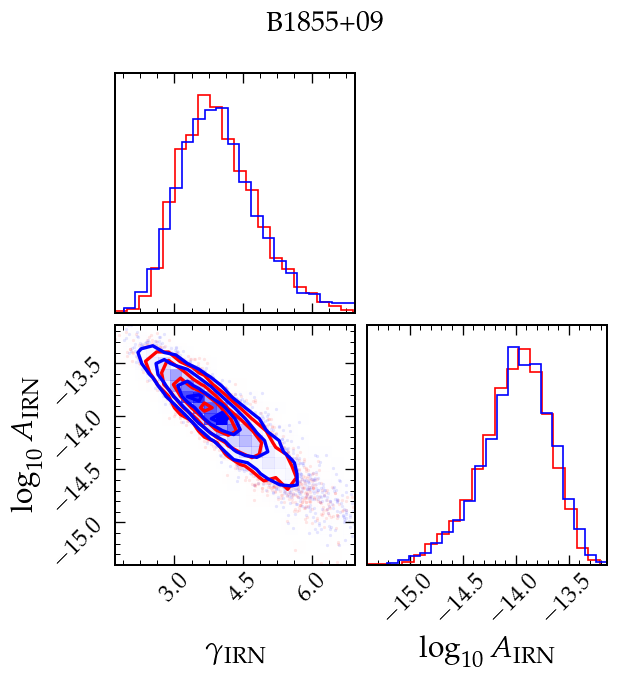

In [36]:
labels = [r"$\gamma_{\rm IRN}$", r"$\log_{10} A_{\rm IRN}$"]

fig = corner.corner(samples_ds_crn, color='r', hist_kwargs={'density': True}, labels=labels)
corner.corner(samples_hyper, color='b', hist_kwargs={'density': True}, fig=fig, labels=labels)
fig.suptitle(summaries[0].name, y=1.02)
plt.savefig(r"mode_hist.pdf", bbox_inches = "tight")
plt.show()

In [38]:
def y_samps_vs_flow_spport(samples, summary, n_dims=3, n_flow_samples=50000, rng_key_val=0):
    
    y_mcmc = np.array(samples["y"])
    y_flow = np.array(summary.flow.sample(jax.random.key(rng_key_val), (n_flow_samples,)))
    labels = [rf"$y_{{{i}}}$" for i in range(n_dims)]

    fig = corner.corner(y_mcmc[:, :n_dims], labels=labels,
                        color="blue", hist_kwargs={"density": True},
                        plot_datapoints=False)
    corner.corner(y_flow[:, :n_dims], fig=fig,
                  color="red", hist_kwargs={"density": True},
                  plot_datapoints=False)

    plt.suptitle(f"{summary.name}", y=1.02)
    #plt.savefig(fr"normal_{summaries[0].eta0.values()}.pdf", bbox_inches="tight")
    plt.show()

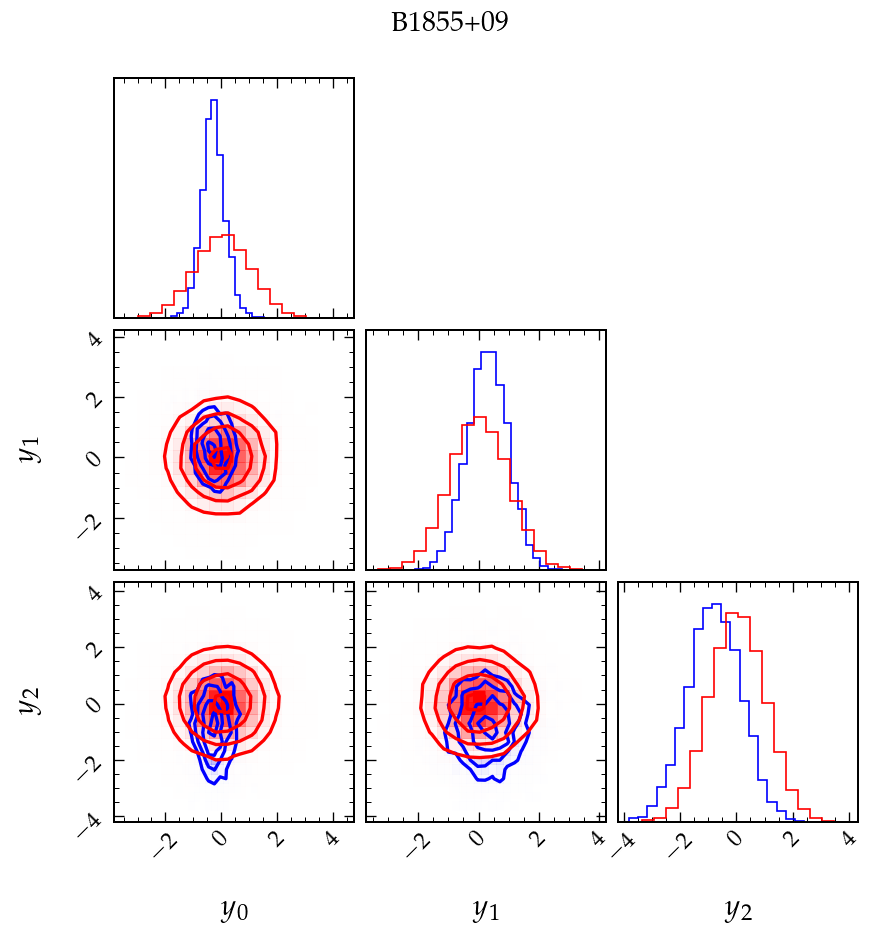

In [39]:
y_samps_vs_flow_spport(psr_samples, summaries[0])

In [46]:
def plot_log_ratio_correction(samples, summary):

    y_mcmc = jnp.array(samples["y"])
    y_gauss = jnp.array(samples["y_gauss"])
    n_coeff = y_mcmc.shape[1]

    log_det_L_f = jnp.sum(jnp.log(jnp.diag(summary.L_f)))
    log_det_L0 = jnp.sum(jnp.log(jnp.diag(summary.L0r)))

    # both evaluated in a-space
    log_p_flow = jax.vmap(summary.flow.log_prob)(y_mcmc) - log_det_L0
    log_p_gauss = (-0.5 * n_coeff * jnp.log(2 * jnp.pi) - log_det_L_f
                   - 0.5 * jnp.sum(y_gauss ** 2, axis=1))

    ratio = jnp.exp(log_p_flow - log_p_gauss)

    plt.hist(np.array(ratio), bins=30, density=True, histtype = 'step', label = r"Step 2 ratio")
    plt.axvline(1,0, color="black", linestyle="--", alpha=0.3)
    plt.xlabel(r"$q_\psi(\mathbf{a})/\mathcal{N}(\mathbf{a} \mid \hat{\mathbf{a}}_f, \boldsymbol{\Sigma}_f ; \boldsymbol{\eta}_0)$")
    
    #plt.hist(np.array(ratio_mc), bins=30, density=True, histtype = 'step', label = r"Step 1 ratio")
    plt.legend()
    
    plt.show()
    



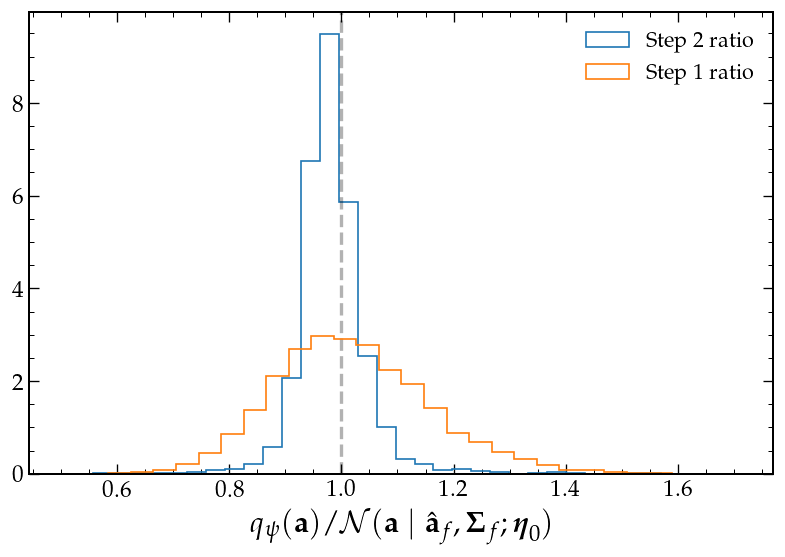

In [45]:
plot_log_ratio_correction(psr_samples, summaries[0])

In [47]:
summaries_linear[0].__dict__

{'name': 'B1855+09',
 'psl': <discovery.likelihood.PulsarLikelihood at 0x172c19bcb90>,
 'eta0': {'log10_A': -13.4, 'gamma': 3.62},
 'phi0_inv': Array([[5.36366612e+10, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 5.36366612e+10, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 6.59462827e+11, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         1.05521872e+16, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 1.19300064e+16, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 1.19300064e+16]], dtype=float64),
 'logdet_phi0': -2022.85555006135,
 'ahat0r': Array([ 1.29803533e-06, -1.03073782e-06,  2.96825505e-07,  2.

In [48]:
# replacing the MCMC estimated ahat_f, L_f with their analytical result for the affine case.
summaries_linear[0].ahat_f = ahat_f_analytic 
summaries_linear[0].L_f = L_f_analytic 

samples = run_step2_SPNA_flow_corrected(summaries_linear[:1], psrs[:1], ds.partial(phi_SPNA, powerlaw= ds.powerlaw), priordict_standard,
                    n_warmup=1024, n_samples=4096)

[1/1] Running step 2 SPNA flow-corrected for B1855+09


sample: 100%|██████████| 5120/5120 [01:07<00:00, 75.32it/s, 15 steps of size 2.01e-01. acc. prob=0.94] 


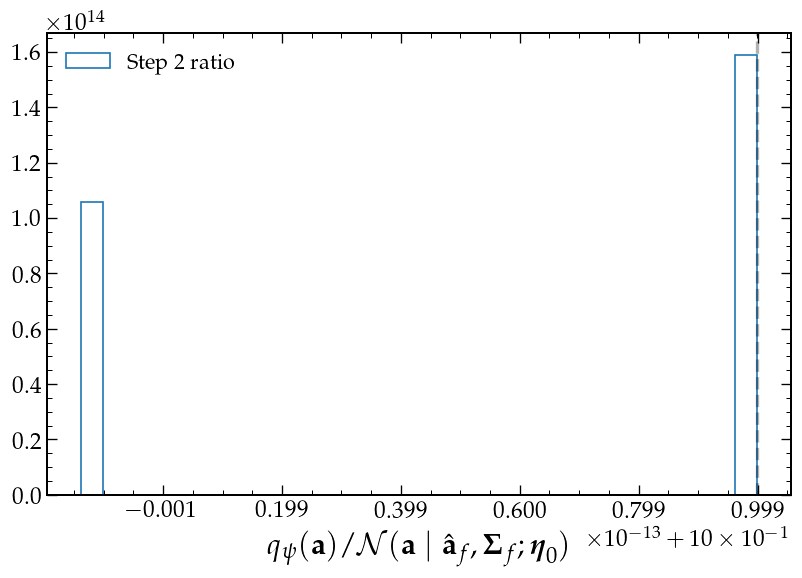

In [49]:
plot_log_ratio_correction(samples[summaries_linear[0].name], summaries_linear[0])

# Running an HD process

In [50]:
commongp = ds.makecommongp_fourier(psrs, ds.powerlaw, components, T=ds.getspan(psrs), name='red_noise')
hdgp = ds.makeglobalgp_fourier(psrs, ds.powerlaw, ds.hd_orf, gw_components, T=ds.getspan(psrs), name='gw')

samples_hd = run_step2_joint_flow_corrected(summaries, psrs, commongp, priordict_standard,
    globalgp=hdgp, gw_components=gw_components,
    n_warmup=1024, n_samples=2048)

sample: 100%|██████████| 3072/3072 [04:25<00:00, 11.58it/s, 63 steps of size 6.35e-02. acc. prob=0.89] 



                                  mean       std    median      5.0%     95.0%     n_eff     r_hat
    B1855+09_red_noise_gamma      3.54      1.66      3.62      0.18      5.97   1649.39      1.00
  B1855+09_red_noise_log10_A    -15.79      2.01    -15.04    -19.03    -13.45    343.55      1.00
    B1937+21_red_noise_gamma      3.91      0.46      3.93      3.21      4.64   1286.93      1.00
  B1937+21_red_noise_log10_A    -13.57      0.09    -13.56    -13.71    -13.42   2580.87      1.00
                    gw_gamma      3.90      1.49      4.07      1.39      6.58    870.46      1.00
                  gw_log10_A    -15.30      1.85    -14.36    -18.63    -13.50    237.45      1.00
                       xi[0]     -0.03      1.01     -0.02     -1.71      1.57   2769.82      1.00
                       xi[1]      0.01      0.98      0.03     -1.53      1.58   3310.98      1.00
                       xi[2]      0.05      0.99      0.05     -1.59      1.67   3410.17      1.00
         

In [ ]:
rn_amp_keys, rn_gamma_keys = create_rn_keys([s.name for s in summaries])

In [ ]:
gw_log10A_key = "gw_log10_A"
gw_gamma_key = "gw_gamma"

mds = ds.ArrayLikelihood([ds.PulsarLikelihood([psr.residuals,
                            ds.makegp_timing(psr, svd=True),
                            ds.makenoise_measurement(psr, noisedict=psr.noisedict, ecorr=True)]) for psr in psrs],
            commongp =commongp,
            globalgp=hdgp)

def log_prior_rho_crn(rho):
    log10As = jnp.array([rho[k] for k in rn_amp_keys] + [rho[gw_log10A_key]])
    gammas  = jnp.array([rho[k] for k in rn_gamma_keys] + [rho[gw_gamma_key]])

    ok = jnp.all((log10As >= -20) & (log10As <= -11)) & jnp.all((gammas >= 0) & (gammas <= 7))
    return jnp.where(ok, 0.0, -jnp.inf)

def potential_ds_hd(rho):
    lp = log_prior_rho_crn(rho)
    return -mds.logL(rho) - lp

init_rho_hd = {
    **{key: eta0_regularizer[i]['log10_A'] for i, key in enumerate(rn_amp_keys)},
    **{key: eta0_regularizer[i]['gamma']   for i, key in enumerate(rn_gamma_keys)},
    gw_log10A_key: -14.0,
    gw_gamma_key:  3.0,}

rng = jax.random.PRNGKey(2)

kernel_ds_hd  = infer.NUTS(potential_fn=potential_ds_hd)
sampler_ds_hd = infer.MCMC(kernel_ds_hd, num_warmup=1024, num_samples=2048,
                            num_chains=1, progress_bar=True)
sampler_ds_hd.run(rng, init_params=init_rho_hd)

samples_ds_hd = sampler_ds_hd.get_samples()
sampler_ds_hd.print_summary()


sample: 100%|██████████| 3072/3072 [04:30<00:00, 11.37it/s, 15 steps of size 5.81e-02. acc. prob=0.87] 


                                  mean       std    median      5.0%     95.0%     n_eff     r_hat
    B1855+09_red_noise_gamma      3.55      1.62      3.71      0.04      5.61     77.73      1.00
  B1855+09_red_noise_log10_A    -15.72      2.10    -14.61    -19.23    -13.40     61.34      1.01
    B1937+21_red_noise_gamma      3.95      0.40      3.96      3.35      4.63    338.66      1.00
  B1937+21_red_noise_log10_A    -13.57      0.09    -13.57    -13.74    -13.44    241.31      1.00
                    gw_gamma      3.95      1.56      4.12      1.30      6.71     97.41      1.01
                  gw_log10_A    -15.55      1.92    -14.54    -18.88    -13.54     85.37      1.02

Number of divergences: 1446


In [ ]:
summaries[0].flow

Transformed(
  base_dist=StandardNormal(shape=(60,)),
  bijection=Invert(
    bijection=Scan(
      bijection=Chain(
        shape=(60,),
        cond_shape=None,
        bijections=(
          MaskedAutoregressive(
            shape=(60,),
            cond_shape=None,
            transformer_constructor=<function get_ravelled_pytree_constructor.<locals>.constructor>,
            masked_autoregressive_mlp=MLP(
              layers=(
                Linear(
                  weight=Parameterize(
                    fn=<function where>,
                    args=(bool[2,16,60], f64[2,16,60], 0),
                    kwargs={}
                  ),
                  bias=f64[2,16],
                  in_features=60,
                  out_features=16,
                  use_bias=True
                ),
                Linear(
                  weight=Parameterize(
                    fn=<function where>,
                    args=(bool[2,16,16], f64[2,16,16], 0),
                    kwargs={}
  

In [ ]:
summaries_linear[0].flow

Transformed(
  base_dist=StandardNormal(shape=(60,)),
  bijection=TriangularAffine(
    shape=(60,),
    loc=f64[60],
    triangular=Parameterize(
      fn=<wrapped function TriangularAffine.__init__.<locals>._to_triangular>,
      args=(f64[60,60],),
      kwargs={}
    ),
    lower=True
  )
)

In [ ]:
# we run the joint analysis using the summary files based on the affine transf.
samples_hd_affine = run_step2_joint_flow_corrected(summaries_linear, psrs, commongp, priordict_standard,
    globalgp=hdgp, gw_components=gw_components,
    n_warmup=1024, n_samples=2048)

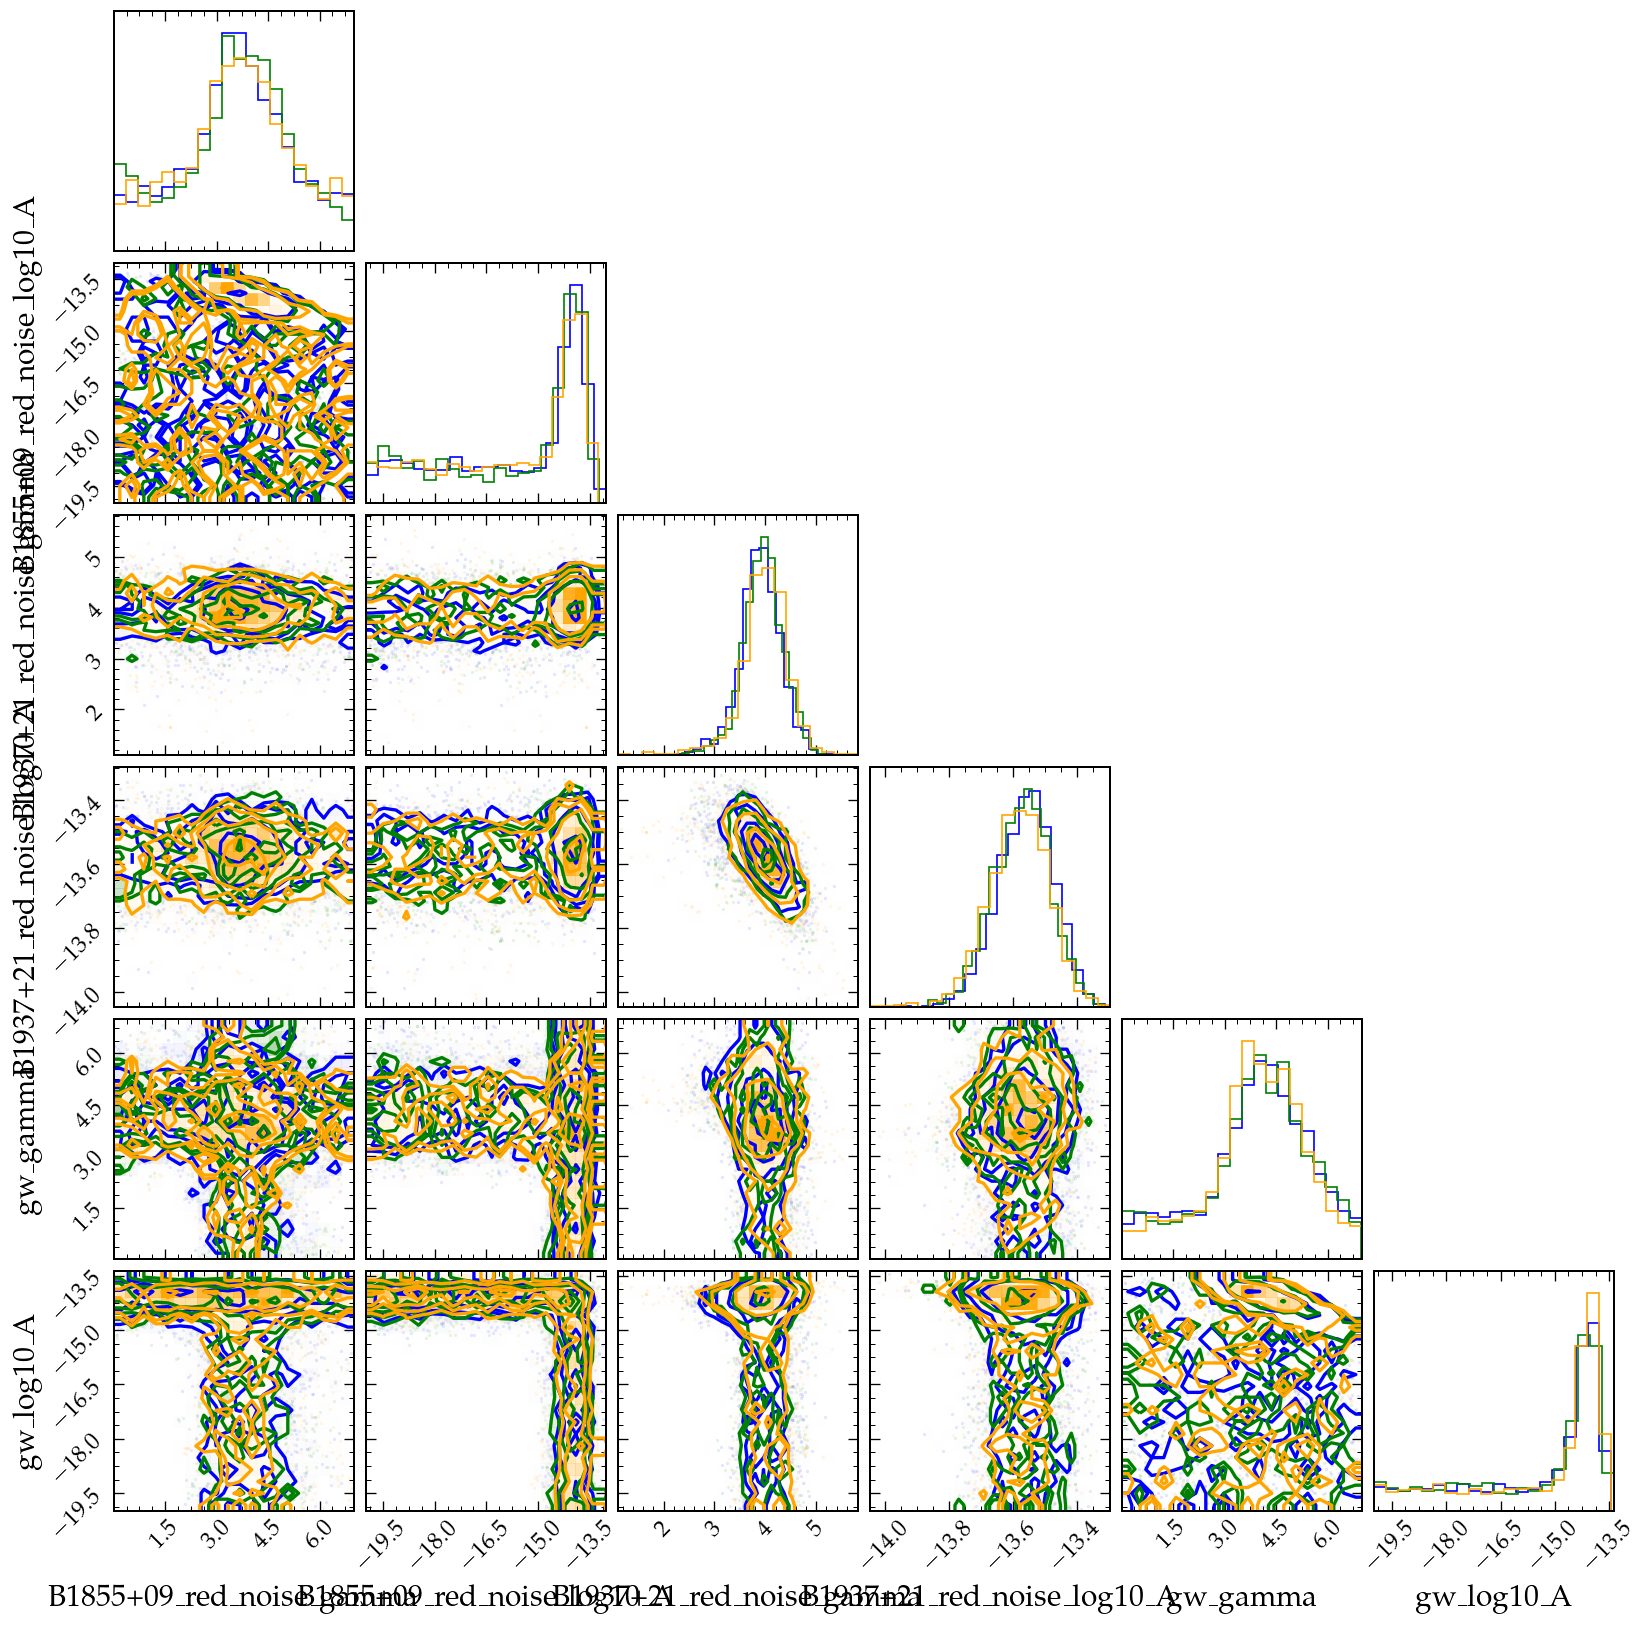

In [ ]:

hyper_keys = [k for k in samples_hd if k not in ("a", "y", "y_gauss", "xi")]

samples_CURN_decentering = {key: samples_hd[key] for key in hyper_keys} # CURN decentering
samples_ds_HD = {key: samples_ds_hd[key] for key in hyper_keys} # DISCOVERY model
samples_hd_affine = {key: samples_hd_affine[key] for key in hyper_keys} # using affine flow

fig = corner.corner(samples_CURN_decentering, color='blue', hist_kwargs={'density': True})
corner.corner(samples_ds_HD, color = 'green', hist_kwargs={'density': True}, fig=fig)
corner.corner(samples_hd_affine, color = 'orange', hist_kwargs={'density': True}, fig=fig)

plt.show()

### Use SGD for running VI

In [57]:
run_step1_flow(summaries, priordict=ds.priordict_standard, learning_rate=1e-2,
               steps=512, batch_size=128, n_flow_samples=100000,
               flow_architecture=affine_flow_architecture,
               optimizer = optax.sgd)

[1/2] Running step 1 for B1855+09
Theta fixed. Using VI.


 44%|████▍     | 225/512 [00:01<00:01, 147.83it/s, loss=-91139.95]


Early stopping at iteration 225
Finished VI flow-fit for pulsar B1855+09.
[2/2] Running step 1 for B1937+21
Theta fixed. Using VI.


 52%|█████▏    | 264/512 [00:01<00:01, 148.84it/s, loss=-328507.42]


Early stopping at iteration 264
Finished VI flow-fit for pulsar B1937+21.
[1/2]: Running flow step for pulsar B1855+09
[2/2]: Running flow step for pulsar B1937+21


# Using varying WN

In [58]:
feathers = pathlib.Path(ds.__path__[0] + '/../../data/')

psrfiles= sorted(feathers.glob("*-[JB]*.feather"))
psrs_sorted = sorted(
    [ds.Pulsar.read_feather(f) for f in psrfiles],
    key=lambda psr: len(psr.toas), reverse=True
)



In [111]:
psrs = psrs_sorted[12:13]

In [112]:
psrs

[<Pulsar J0613-0200: 17124 res, 193 pars>]

### Sampling over ECORR

In [113]:
components = 30
gw_components = 14
powerlaw = ds.powerlaw
Tspan = ds.getspan(psrs)


eta0_prime = {"log10_A": -13.5, "gamma": 0.0} 
eta0_regularizer, results = compute_eta_MAP(psrs, powerlaw=powerlaw,
                                          priordict=priordict_standard,
                                          eta0_prime=eta0_prime,
                                          n_grid = 15, steps = 4,
                                          zoom = 0.5)




J0613-0200:
eta MAP: gamma=2.81, log10_A=-13.65
informative with ratio = 0.34


In [115]:
eta0_regularizer = [{'log10_A': -13.2, 'gamma': 2.8}] # important to not set gamma to values exactly on prior boundary
                                    # since the sampler will not like being initiated there

In [116]:
noisedicts = [{}]
summaries = build_fourier_psr_summaries(
    psrs, eta0_list  = eta0_regularizer,
    powerlaw = powerlaw, components = components,
    noisedict_list = noisedicts,
    psr_class_obj = FlowPulsarFourierSummary)

In [117]:
summaries[0].psl.logL.params

['J0613-0200_Rcvr1_2_GASP_efac',
 'J0613-0200_Rcvr1_2_GASP_log10_ecorr',
 'J0613-0200_Rcvr1_2_GASP_log10_t2equad',
 'J0613-0200_Rcvr1_2_GUPPI_efac',
 'J0613-0200_Rcvr1_2_GUPPI_log10_ecorr',
 'J0613-0200_Rcvr1_2_GUPPI_log10_t2equad',
 'J0613-0200_Rcvr_800_GASP_efac',
 'J0613-0200_Rcvr_800_GASP_log10_ecorr',
 'J0613-0200_Rcvr_800_GASP_log10_t2equad',
 'J0613-0200_Rcvr_800_GUPPI_efac',
 'J0613-0200_Rcvr_800_GUPPI_log10_ecorr',
 'J0613-0200_Rcvr_800_GUPPI_log10_t2equad']

In [ ]:
run_step1_flow(summaries, priordict=ds.priordict_standard, learning_rate = 1e-2,
               steps = 512, batch_size = 128, n_flow_samples=100000)

In [ ]:
compute_gauss_approx_to_flow(summaries[0], jax.random.key(0), int(1e6)) # using 1 million samples instead for the Gauss flow approx.

In [ ]:
samples = run_step2_SPNA_flow_corrected(summaries[:1], psrs[:1], ds.partial(phi_SPNA, powerlaw= ds.powerlaw), priordict_standard,
                    n_warmup=1024, n_samples=4096)

In [ ]:
samples = samples[summaries[0].name]
samples_irn = {key: samples[key] for key in rn_gamma_keys + rn_amp_keys}

In [ ]:
samples_irn

{'J1802-2124_red_noise_log10_A': Array([-12.28863864, -12.32870907, -12.1160431 , ..., -12.03247231,
        -12.13113307, -12.3227912 ], dtype=float64),
 'J1802-2124_red_noise_gamma': Array([1.60009379, 2.16376752, 1.79058073, ..., 2.1100769 , 2.11146602,
        1.40663394], dtype=float64)}

In [ ]:
m_SPNA = ds.ArrayLikelihood([ds.PulsarLikelihood([psr.residuals,
                            ds.makegp_timing(psr, svd=True),
                            ds.makenoise_measurement(psr, noisedict=psr.noisedict, ecorr=True),
                             ds.makegp_fourier(psr, powerlaw, 30, name='red_noise', T=ds.getspan(psrs))]) for psr in psrs])
                          

In [ ]:
rn_amp_keys, rn_gamma_keys = create_rn_keys([psr.name for psr in psrs])

In [ ]:
def log_prior_rho(rho):
    
    log10As = jnp.array([rho[k] for k in rn_amp_keys])# + [rho[crn_log10A_key]])
    gammas  = jnp.array([rho[k] for k in rn_gamma_keys])# + [rho[crn_gamma_key]])

    ok = jnp.all((log10As >= -20) & (log10As <= -11)) & jnp.all((gammas >= 0) & (gammas <= 7))
    log_prior_val = jnp.where(ok, 0.0, -jnp.inf)
    return log_prior_val

def potential_ds(rho):
        lp = log_prior_rho(rho)
        return - m_SPNA.logL(rho) - lp
    
init_params = {**{k: summaries[0].eta0["log10_A"] for i, k in enumerate(rn_amp_keys)},
                **{k: summaries[0].eta0["gamma"] +1e-4 for i, k in enumerate(rn_gamma_keys)},
                "xi": jnp.zeros(npsr * 2 * 30)}


kernel_ds_SPNA = infer.NUTS(potential_fn=potential_ds,
                           init_strategy=infer.init_to_value(values=init_params))
sampler_ds_SPNA = infer.MCMC(kernel_ds_SPNA, num_warmup=1024, num_samples=4096, num_chains=1, progress_bar=True)
init_rho_crn = {**{key: -13.0 for key in rn_amp_keys},
    **{key: 4.0 for key in rn_gamma_keys}}
    #crn_log10A_key: -16.0,
    #crn_gamma_key: 4.0}

sampler_ds_SPNA.run(jax.random.key(1), init_params=init_rho_crn)

samples_ds_SPNA = sampler_ds_SPNA.get_samples()



In [ ]:
sampler_ds_SPNA.print_summary()


                                    mean       std    median      5.0%     95.0%     n_eff     r_hat
    J1802-2124_red_noise_gamma      1.81      0.71      1.74      0.68      2.82   1259.55      1.00
  J1802-2124_red_noise_log10_A    -12.25      0.16    -12.25    -12.48    -11.98   1241.71      1.00

Number of divergences: 63


In [ ]:
samples_irn

{'J1802-2124_red_noise_log10_A': Array([-12.28863864, -12.32870907, -12.1160431 , ..., -12.03247231,
        -12.13113307, -12.3227912 ], dtype=float64),
 'J1802-2124_red_noise_gamma': Array([1.60009379, 2.16376752, 1.79058073, ..., 2.1100769 , 2.11146602,
        1.40663394], dtype=float64)}

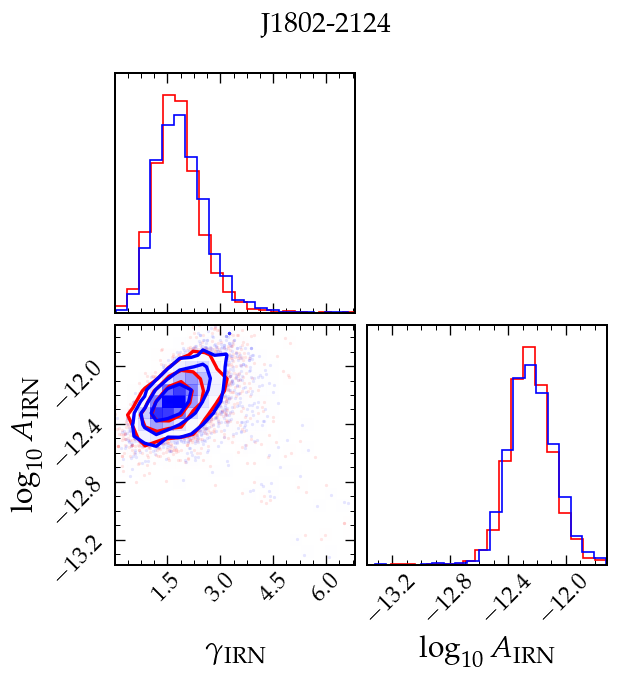

In [ ]:
labels = [r"$\gamma_{\rm IRN}$", r"$\log_{10} A_{\rm IRN}$"]

fig = corner.corner(samples_ds_SPNA, color='r', hist_kwargs={'density': True}, labels=labels)
corner.corner(samples_irn, color='b', hist_kwargs={'density': True}, fig=fig, labels=labels)
fig.suptitle(summaries[0].name, y=1.02)
plt.savefig(r"mode_hist.pdf", bbox_inches = "tight")
plt.show()

### HD process with WN marginalization

In [4]:
feathers = pathlib.Path(ds.__path__[0] + '/../../data/')

psrfiles= sorted(feathers.glob("*-[JB]*.feather"))
psrs_sorted = sorted(
    [ds.Pulsar.read_feather(f) for f in psrfiles],
    key=lambda psr: len(psr.toas), reverse=True)



In [5]:
psrs = psrs_sorted[12:16]

In [ ]:
components = 30
gw_components = 14
powerlaw = ds.powerlaw
Tspan = ds.getspan(psrs)


eta0_prime = {"log10_A": -13.5, "gamma": 0.0} 
eta0_regularizer, results = compute_eta_MAP(psrs, powerlaw=powerlaw,
                                          priordict=priordict_standard,
                                          eta0_prime=eta0_prime,
                                          n_grid = 15, steps = 4,
                                          zoom = 0.5, ecorr = False)




J0613-0200:
eta MAP: gamma=2.62, log10_A=-13.57
informative with ratio = 0.38

J2010-1323:
eta MAP: gamma=0.50, log10_A=-13.25
informative with ratio = 0.29

J0023+0923:
eta MAP: gamma=0.35, log10_A=-13.25
informative with ratio = 0.33

J1640+2224:
eta MAP: gamma=0.00, log10_A=-12.94
informative with ratio = 0.21


In [8]:
noisedicts = [{}]*4
summaries = build_fourier_psr_summaries(
    psrs, eta0_list  = eta0_regularizer,
    powerlaw = powerlaw, components = components,
    noisedict_list = noisedicts,
    psr_class_obj = FlowPulsarFourierSummary)

In [ ]:
run_step1_flow(summaries, priordict=ds.priordict_standard, learning_rate = 1e-2,
               steps = 512, batch_size = 128, n_flow_samples=100000)

[1/4] Running step 1 for J0613-0200
Starting sampling for J0613-0200.


warmup:   1%|          | 14/1280 [07:57<19:48:31, 56.33s/it, 255 steps of size 1.11e-02. acc. prob=0.64] 